In [162]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

In [163]:
test = json.loads(open('../info.json', 'r', encoding='utf-8').read()).get('test') 
test

1

In [164]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)

# DADOS MEASURE

In [165]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df

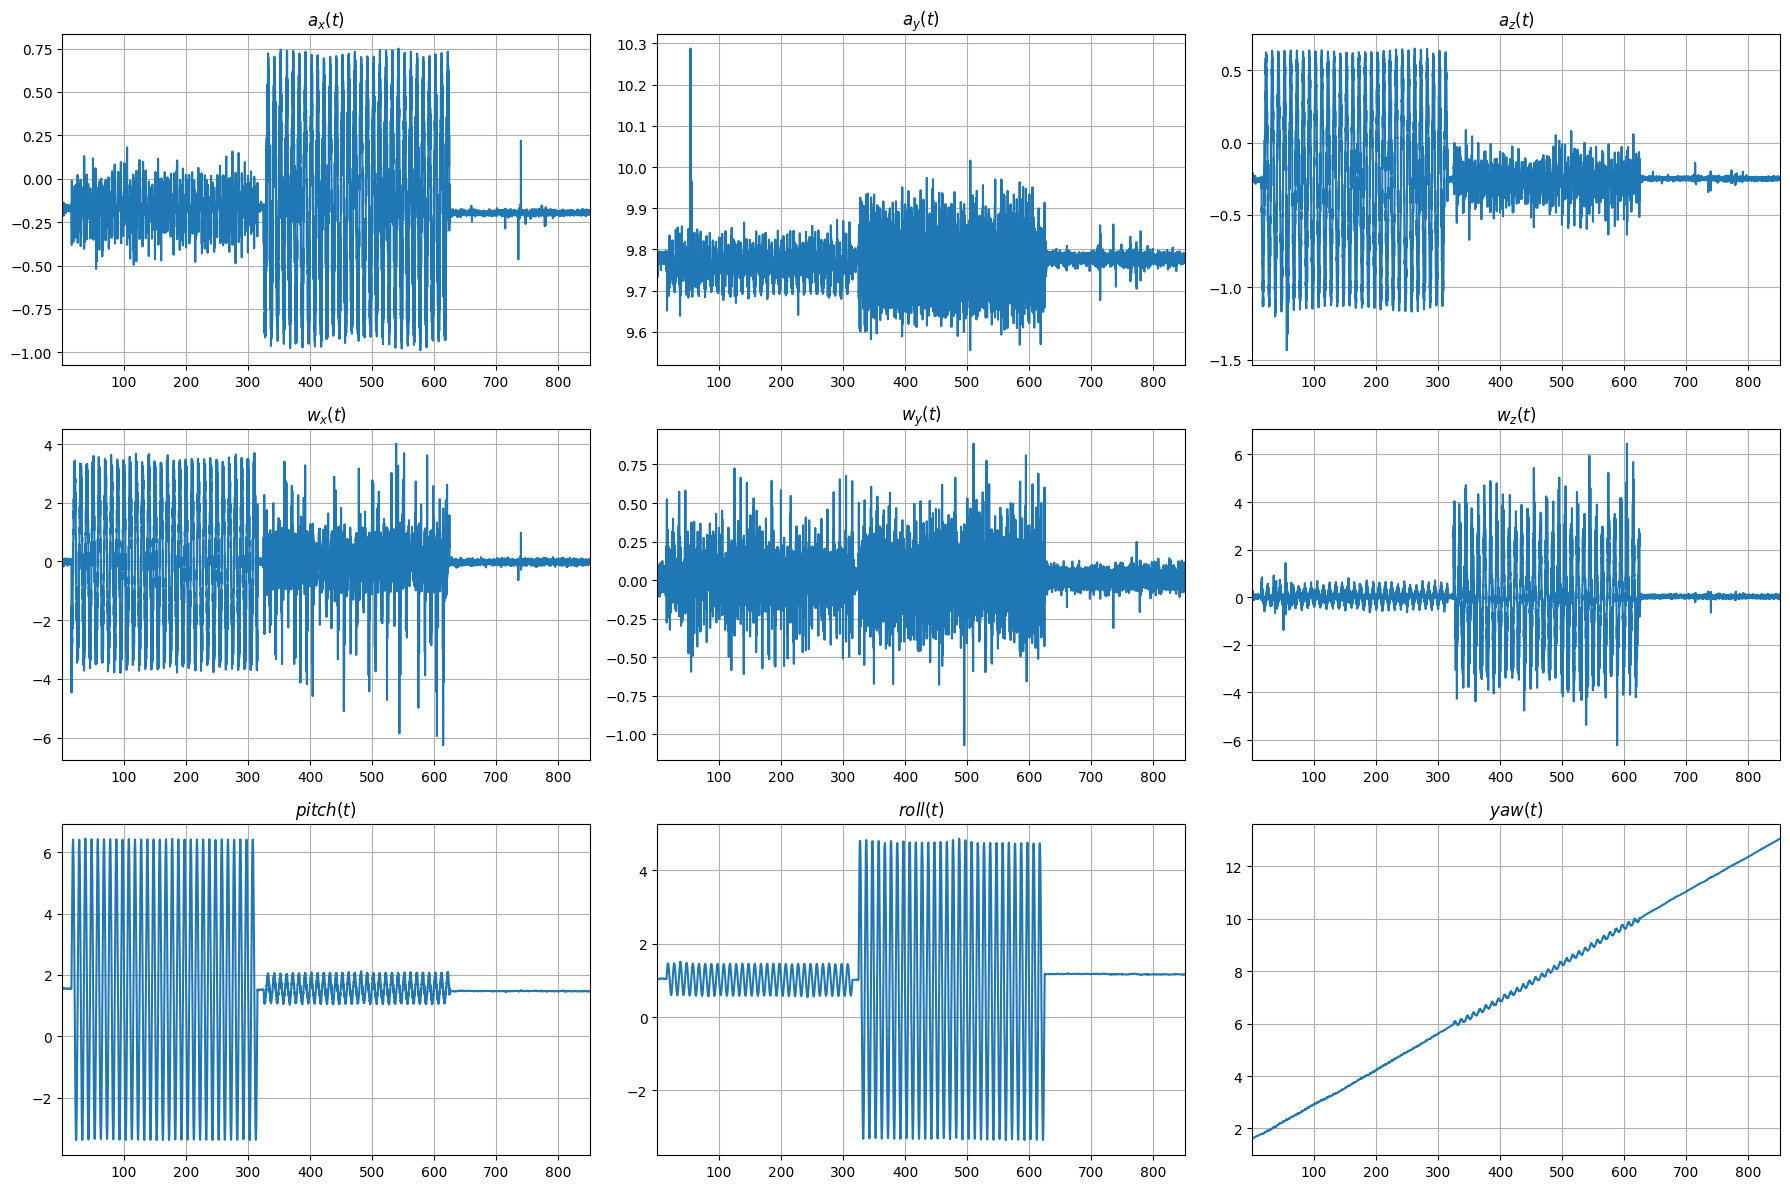

In [166]:
df_target = pd.read_csv(f'files/test{test}/target/data.csv')
df_target = convertAxis(df_target)

df_target = switchColumns(df_target, 'wy', 'wz')
df_target = switchColumns(df_target, 'ay', 'az')

df_target['pitch'] = -df_target['pitch']
df_target['wy']    = -df_target['wy']

plotAll(df_target, limits=(0, 0.5))

### FILTROS

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import signal

0.1
testing target_ax


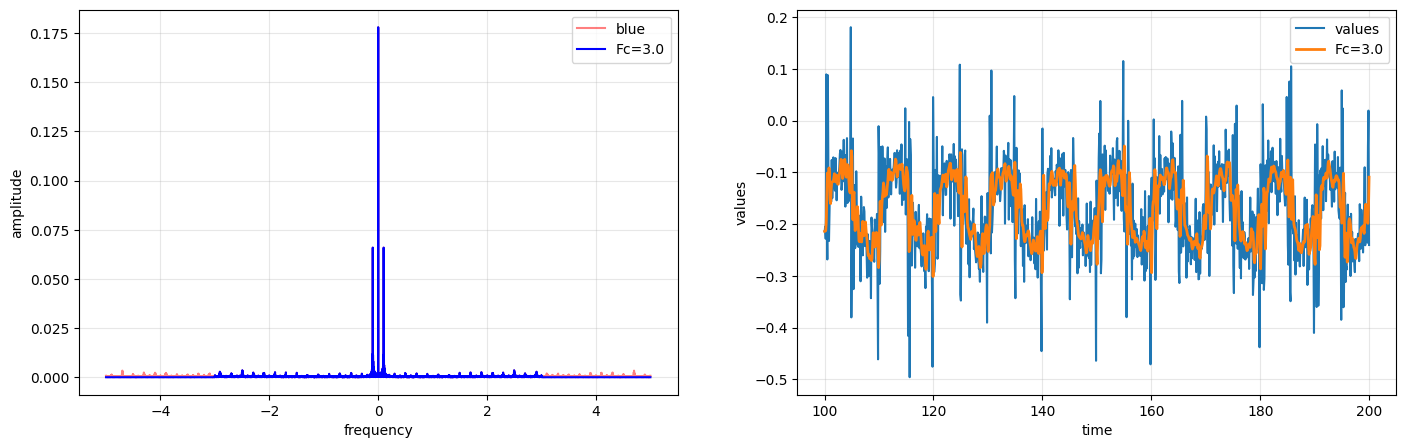

testing target_ay


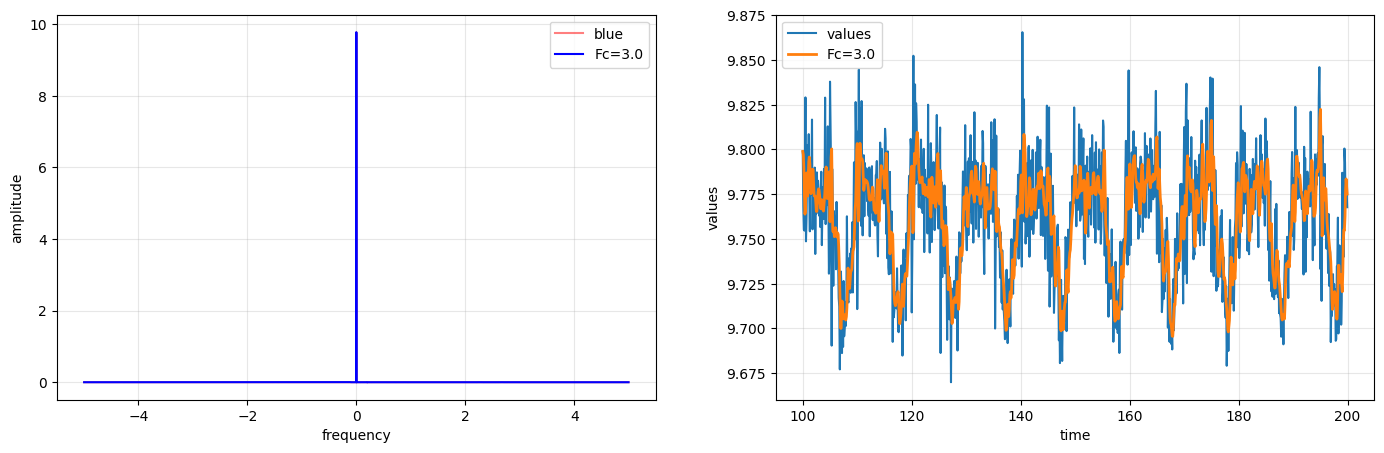

testing target_az


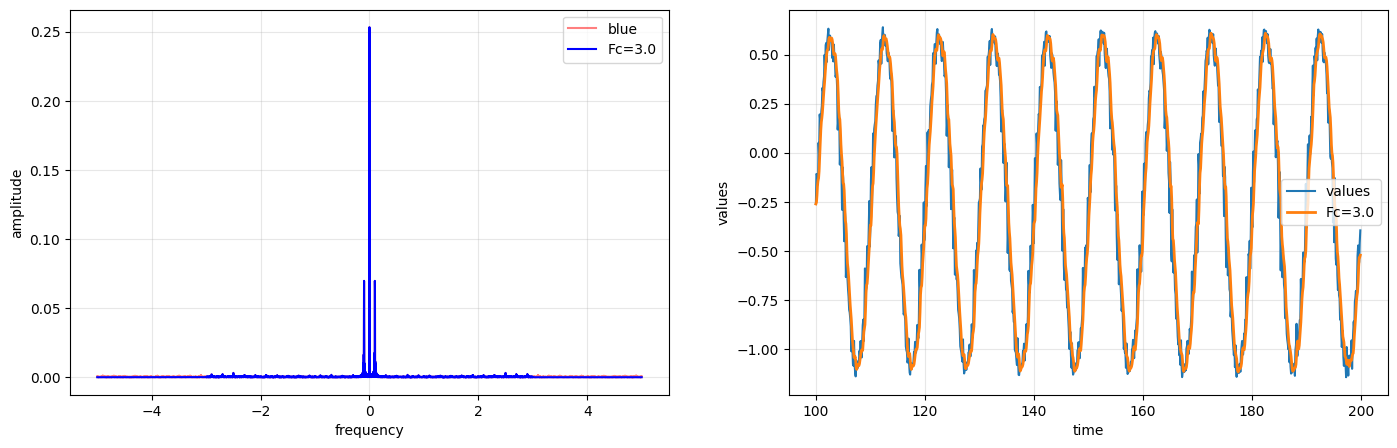

testing target_wx


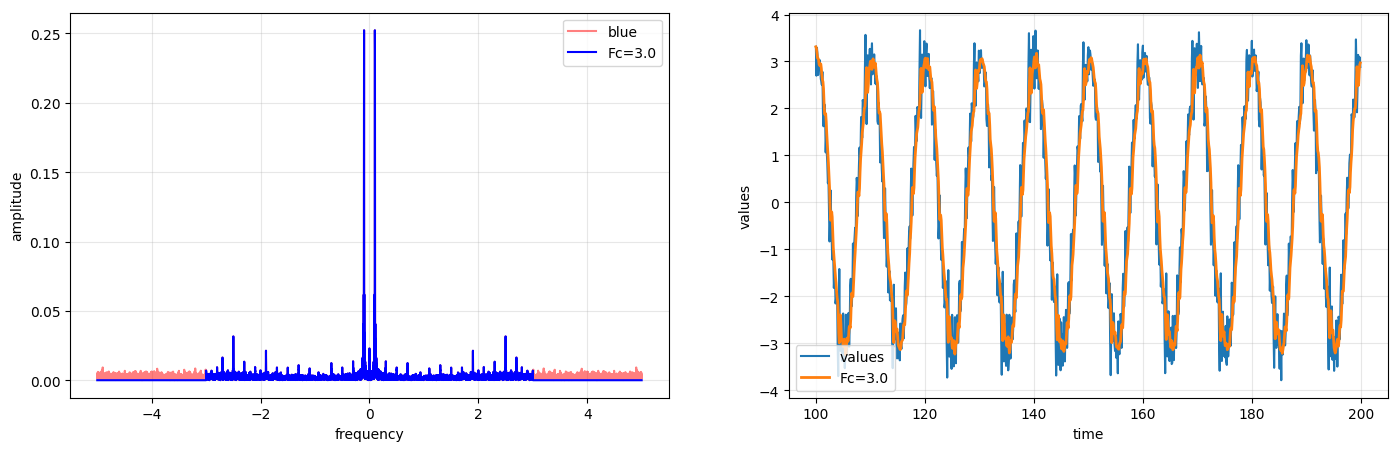

testing target_wy


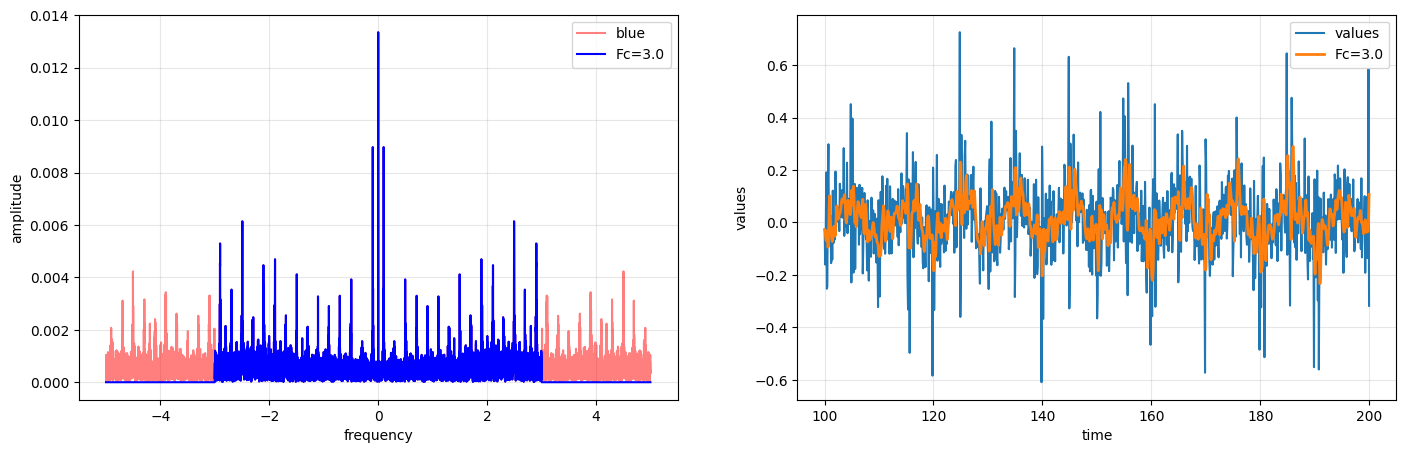

testing target_wz


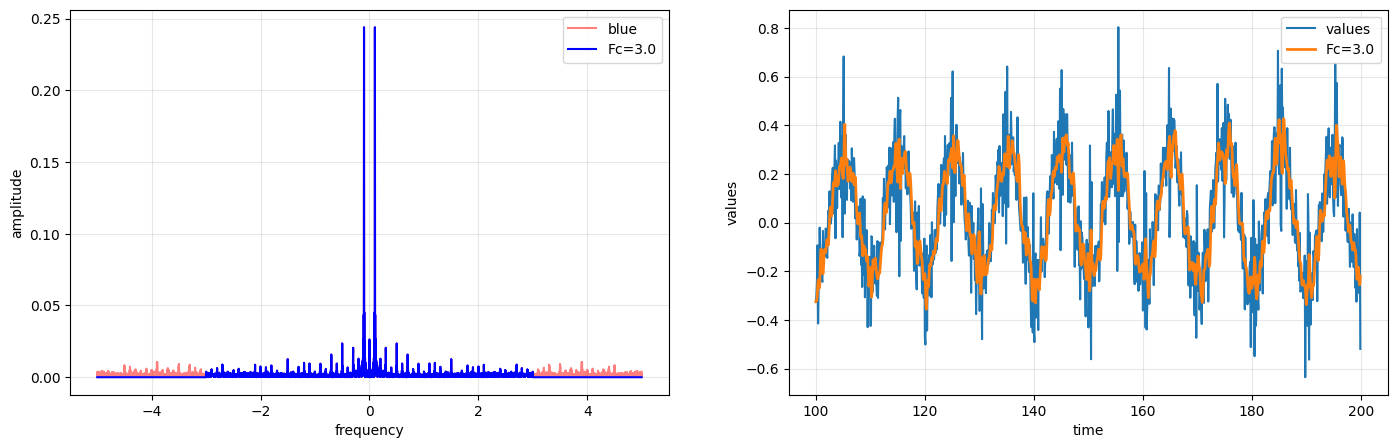

In [168]:
class FrequencyAnalyzer:
    def __init__(self, xData, yData):
        self.xData = np.asarray(xData)
        self.yData = np.asarray(yData)
        
        self.dt = np.mean(np.diff(self.xData))
        self.nSamples = len(self.yData)
        
        self.yFreq = None
        self.yMag  = None

    def update(self):
        fftResult  = np.fft.fft(self.yData)
        freqs      = np.fft.fftfreq(self.nSamples, self.dt)
        self.yFreq = np.fft.fftshift(freqs)
        self.yMag  = np.fft.fftshift(np.abs(fftResult)) / self.nSamples

    def plot(self, xLim=None, yLim=None, Fc=None):
        self.update()
        plt.plot(self.yFreq, self.yMag, label='blue', color='red', alpha=0.5)

        if Fc is not None:
            yMagRestricted = self.yMag.copy()
            allowed = (np.abs(self.yFreq) <= Fc)
            yMagRestricted[~allowed] = 0
            plt.plot(self.yFreq, yMagRestricted, label=f'Fc={Fc}', color='blue')
        
        plt.xlabel('frequency')
        plt.ylabel('amplitude')
        plt.grid(alpha=0.3)
        
        if xLim: plt.xlim(xLim)
        if yLim: plt.ylim(yLim)
        plt.legend()


class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc
        
        Wc = (2 * np.pi * Fc)
        num_c = [Wc**4]
        den_c = [1, 4*Wc, 6*(Wc**2), 4*(Wc**3), Wc**4]
        
        C = signal.cont2discrete((num_c, den_c), dt, method='bilinear')
        self.num, self.den = self.getFraction(C)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))

    def getFraction(self, C):
        num = np.squeeze(C[0])
        den = np.squeeze(C[1])
        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        out = 0.0
        for i in range(len(self.num)):
            out += self.Xn[i] * self.num[i]
        
        for i in range(1, len(self.den)):
            out -= self.Yn[i] * self.den[i]

        return out

    def update(self, inputValue):
        for n in range(len(self.num)-1, 0, -1):
            self.Xn[n] = self.Xn[n-1]

        for n in range(len(self.den)-1, 0, -1):
            self.Yn[n] = self.Yn[n-1]
        
        self.Xn[0] = inputValue
        self.Yn[0] = self.compute()
        
        return self.Yn[0] if self.Fc > 0 else inputValue

    def apply(self, yData):
        yData = np.array(yData)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))
        
        if len(yData) > 0 and self.Fc > 0:
            for i in range(100): 
                self.update(yData[0])
        
        return np.array([self.update(val) for val in yData])

    def test(self, df, var, xLim, yLim, limits=(0, 100)):
        plt.figure(figsize=(17, 5))
        
        plt.subplot(1, 2, 1)
        print('testing', var)
        FrequencyAnalyzer(df.time, df[var]).plot(xLim, yLim, Fc=self.Fc)

        plt.subplot(1, 2, 2)
        target = df.loc[(df.time >= limits[0]) & (df.time <= limits[1])]
        plt.plot(target.time, target[var], label='values')
        plt.plot(target.time, self.apply(target[var]), label=f'Fc={self.Fc}', linewidth=2)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.xlabel('time')
        plt.ylabel('values')
        plt.show()
        df[var] = self.apply(df[var])
        return df.copy()


dt     = round((df_target.time.values[2] - df_target.time.values[0])/2, 2)
limits = (100, 200) 
print(dt)

for var in ['ax', 'ay', 'az']:
    df = LowPassFilter(Fc=3.0, dt=dt).test(df, 'target_' + var, xLim=None, yLim=None, limits=limits)

for var in ['wx', 'wy', 'wz']:
    df = LowPassFilter(Fc=3.0, dt=dt).test(df, 'target_' + var, xLim=None, yLim=None, limits=limits)

# DADOS KONGSBERG

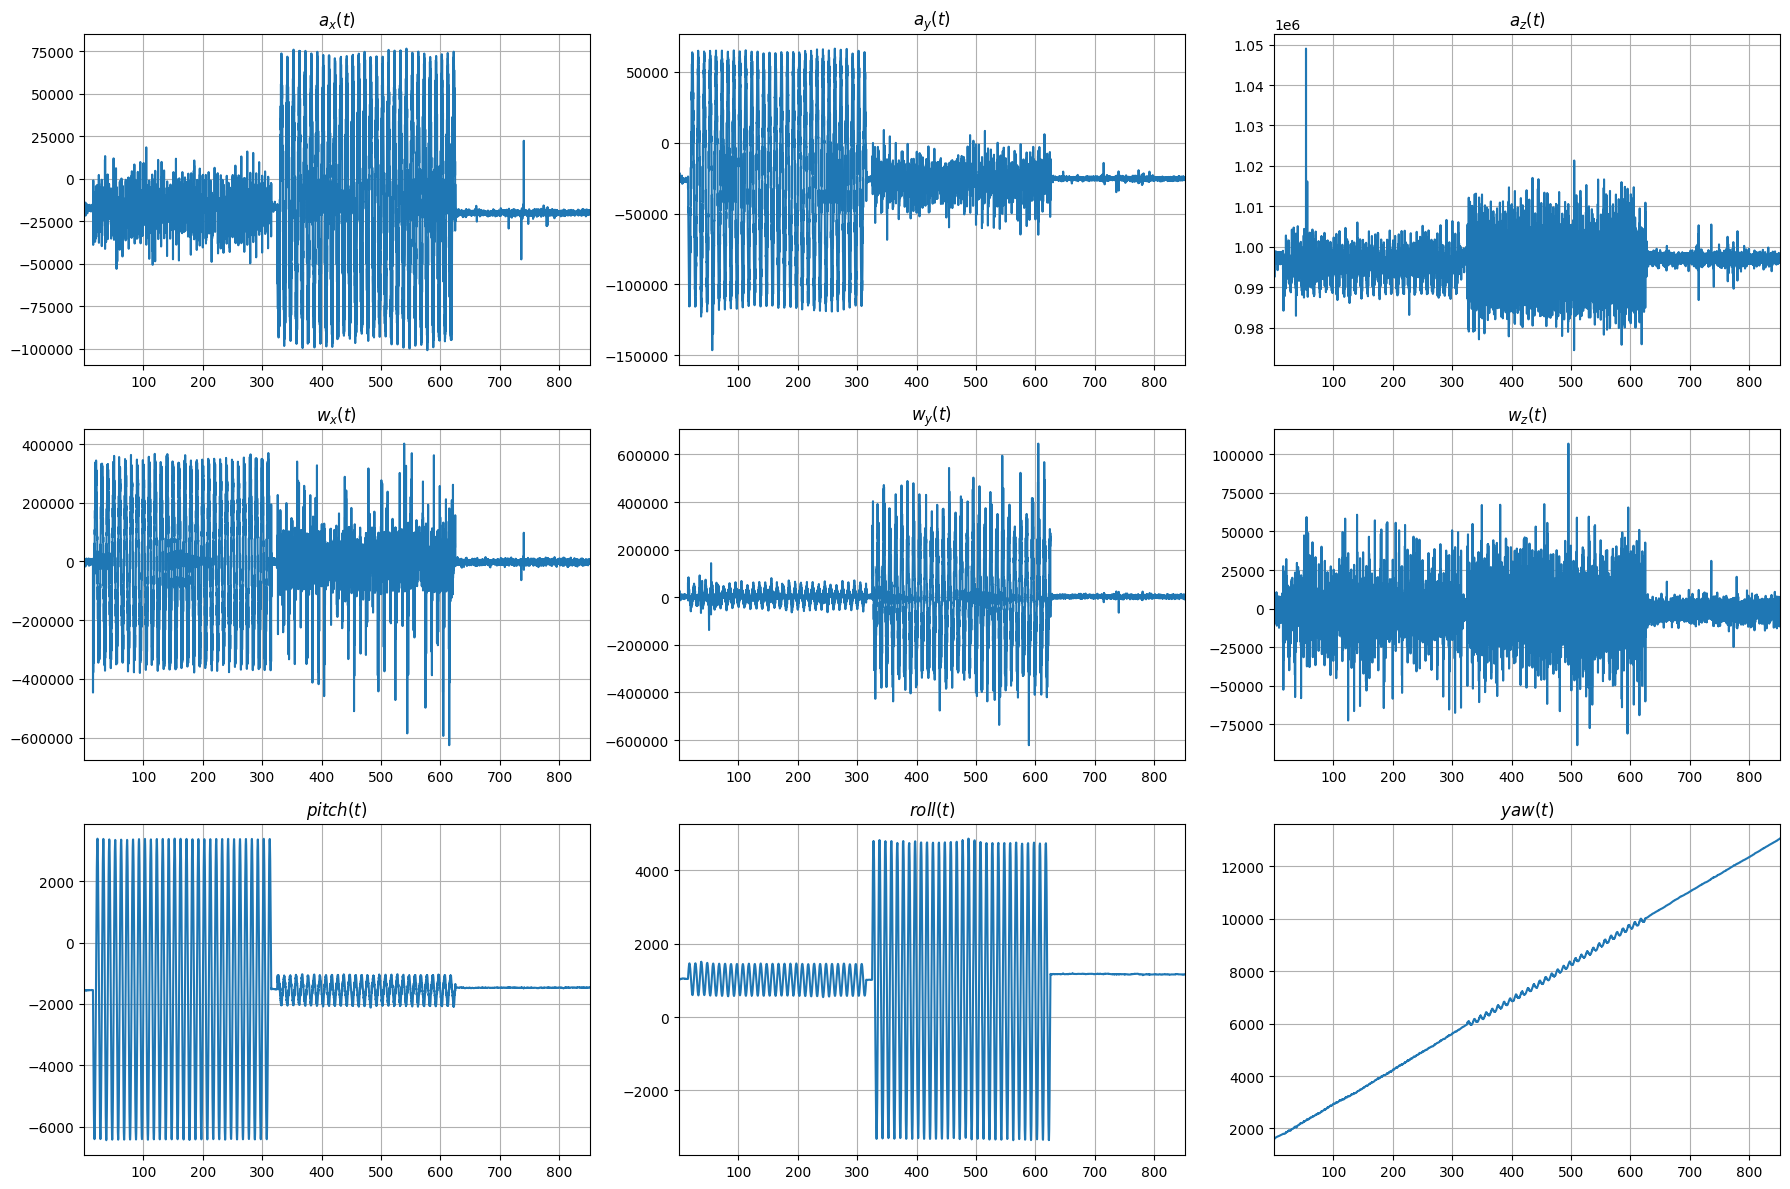

In [169]:
df_mru = pd.read_csv(f'files/test{test}/mru/data.csv')
plotAll(df_mru, limits=(0, 0.5))

# DADOS MESA

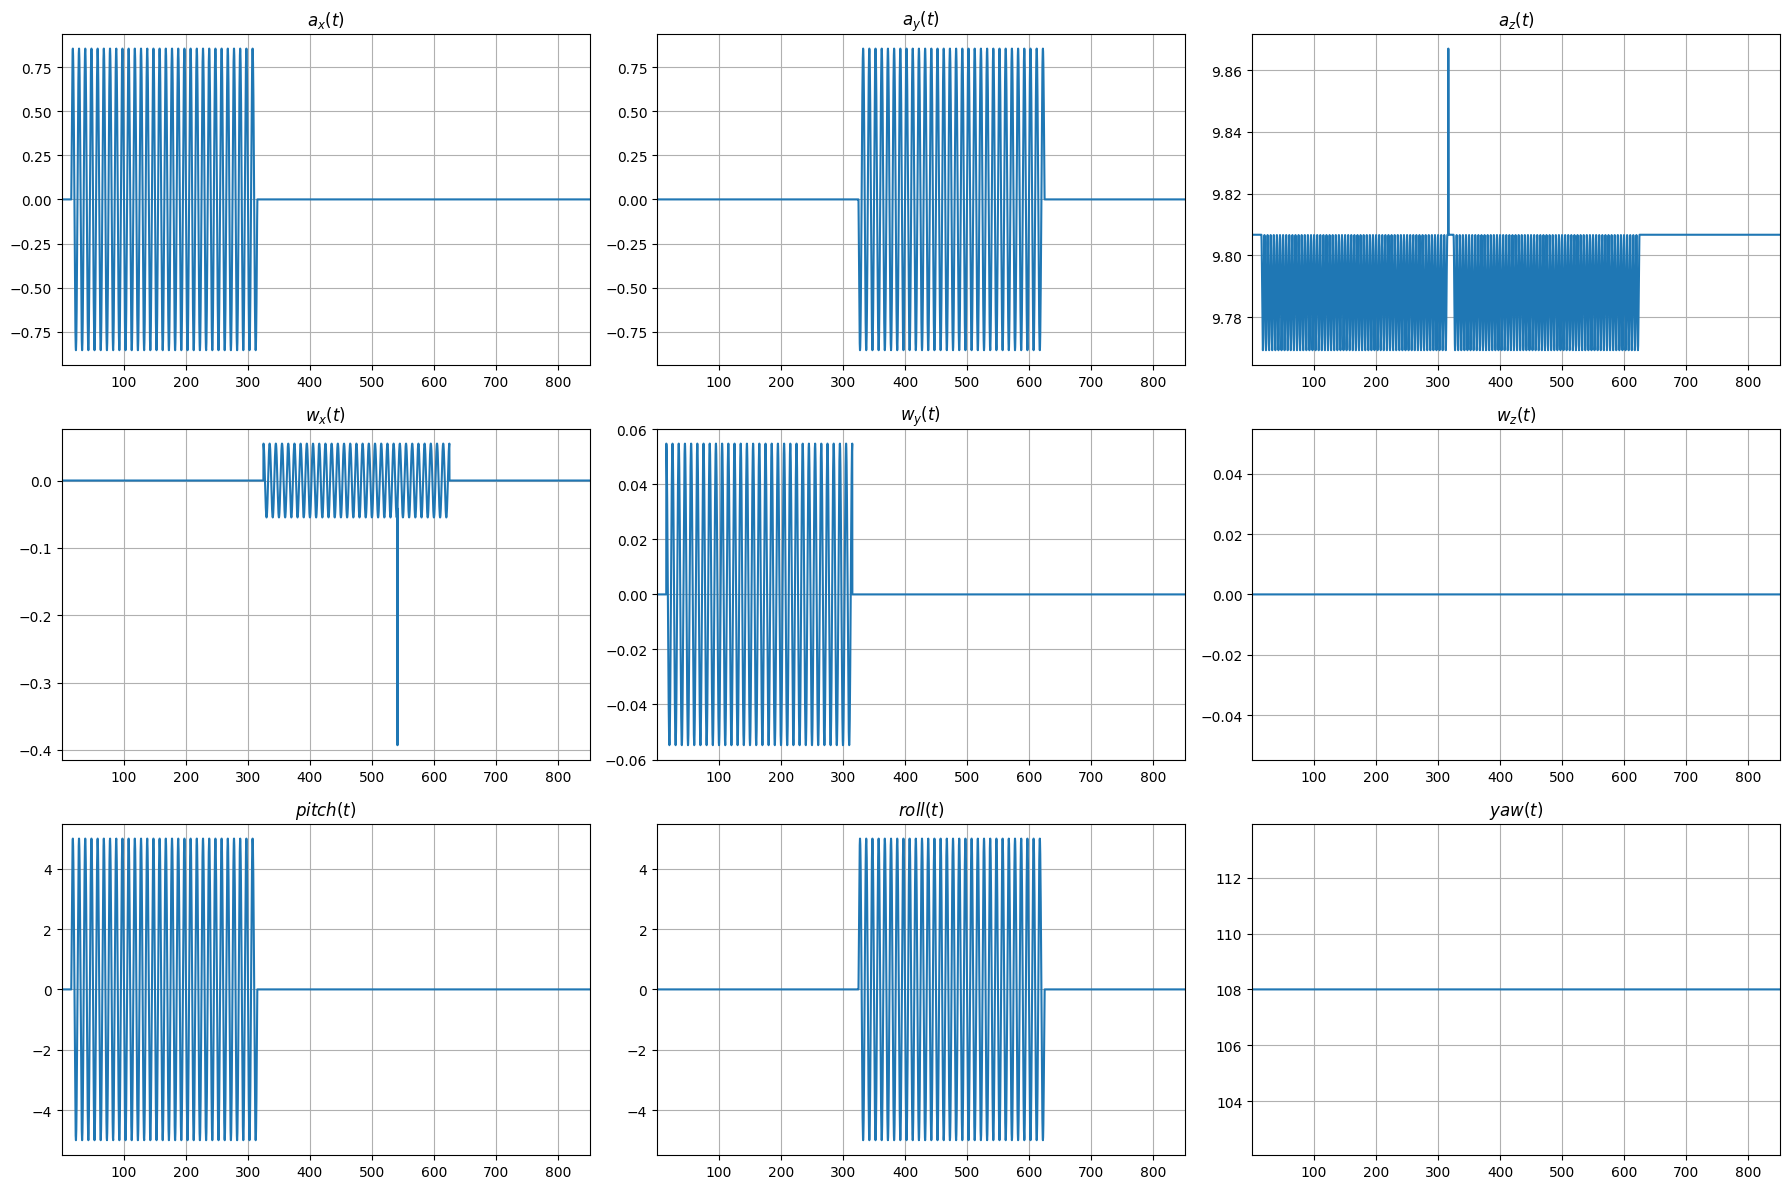

In [170]:
df_ref = pd.read_csv(f'files/test{test}/reference/data.csv')
plotAll(df_ref, limits=(0, 0.5))

# JUNTANDO TABELAS

In [171]:
df_target = df_target.rename(columns={col: 'target_' + col for col in df_target.columns if col not in ['time']})
df_target.head()

,target_wz,target_az,target_yaw,target_ax,target_h,time,target_pitch,target_ay,target_wx,target_wy,target_roll,target_tmp
0,0.10067,-0.270526,1.551,-0.173754,-0.024,7.152557e-07,1.548,9.786821,-0.04969,0.02252,1.043,43.8
1,0.01753,-0.258072,1.565,-0.171538,-0.022,9.435034e-02,1.546,9.779888,0.07862,0.00236,1.038,43.7
2,-0.06852,-0.248520,1.572,-0.157554,-0.019,2.007830e-01,1.549,9.791499,-0.11278,0.04887,1.032,43.8
3,0.03072,-0.275959,1.578,-0.169537,-0.017,2.974703e-01,1.549,9.768649,-0.04654,0.01132,1.031,43.7
4,-0.01811,-0.270291,1.592,-0.161339,-0.014,4.027123e-01,1.556,9.781780,-0.00709,0.02012,1.039,43.7


In [172]:
df_mru = df_mru.rename(columns={col: 'mru_' + col for col in df_mru.columns if col not in ['time']})
df_mru.head()

,mru_wz,mru_az,mru_yaw,mru_ax,mru_h,time,mru_pitch,mru_ay,mru_wx,mru_wy,mru_roll,mru_tmp
0,-2252.0,997978.0,1551.0,-17718.0,-0.024,7.152557e-07,-1548.0,-27586.0,-4969.0,10067.0,1043.0,43.8
1,-236.0,997271.0,1565.0,-17492.0,-0.022,9.435034e-02,-1546.0,-26316.0,7862.0,1753.0,1038.0,43.7
2,-4887.0,998455.0,1572.0,-16066.0,-0.019,2.007830e-01,-1549.0,-25342.0,-11278.0,-6852.0,1032.0,43.8
3,-1132.0,996125.0,1578.0,-17288.0,-0.017,2.974703e-01,-1549.0,-28140.0,-4654.0,3072.0,1031.0,43.7
4,-2012.0,997464.0,1592.0,-16452.0,-0.014,4.027123e-01,-1556.0,-27562.0,-709.0,-1811.0,1039.0,43.7


In [173]:
df_ref = df_ref.rename(columns={col: 'ref_' + col for col in df_ref.columns if col not in ['time']})
df_ref.head()

,ref_wz,ref_az,ref_yaw,ref_ax,ref_h,time,ref_pitch,ref_ay,ref_wx,ref_wy,ref_roll,ref_tmp
0,0.0,9.8067,108.0,0.0,0.0,7.152557e-07,0.0,-0.0,0.0,0.0,0.0,0.0
1,0.0,9.8067,108.0,0.0,0.0,9.435034e-02,0.0,-0.0,0.0,0.0,0.0,0.1
2,0.0,9.8067,108.0,0.0,0.0,2.007830e-01,0.0,-0.0,0.0,0.0,0.0,0.2
3,0.0,9.8067,108.0,0.0,0.0,2.974703e-01,0.0,-0.0,0.0,0.0,0.0,0.3
4,0.0,9.8067,108.0,0.0,0.0,4.027123e-01,0.0,-0.0,0.0,0.0,0.0,0.4


In [174]:
df = pd.merge_asof(df_target, df_ref, on='time', direction='nearest')
df = pd.merge_asof(df, df_mru, on='time', direction='nearest')
df

,target_wz,target_az,target_yaw,target_ax,target_h,time,target_pitch,target_ay,target_wx,target_wy,target_roll,target_tmp,ref_wz,ref_az,ref_yaw,ref_ax,ref_h,ref_pitch,ref_ay,ref_wx,ref_wy,ref_roll,ref_tmp,mru_wz,mru_az,mru_yaw,mru_ax,mru_h,mru_pitch,mru_ay,mru_wx,mru_wy,mru_roll,mru_tmp
0,0.10067,-0.270526,1.551,-0.173754,-0.024,7.152557e-07,1.548,9.786821,-0.04969,0.02252,1.043,43.8,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.000,-2252.0,997978.0,1551.0,-17718.0,-0.024,-1548.0,-27586.0,-4969.0,10067.0,1043.0,43.8
1,0.01753,-0.258072,1.565,-0.171538,-0.022,9.435034e-02,1.546,9.779888,0.07862,0.00236,1.038,43.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.100,-236.0,997271.0,1565.0,-17492.0,-0.022,-1546.0,-26316.0,7862.0,1753.0,1038.0,43.7
2,-0.06852,-0.248520,1.572,-0.157554,-0.019,2.007830e-01,1.549,9.791499,-0.11278,0.04887,1.032,43.8,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.200,-4887.0,998455.0,1572.0,-16066.0,-0.019,-1549.0,-25342.0,-11278.0,-6852.0,1032.0,43.8
3,0.03072,-0.275959,1.578,-0.169537,-0.017,2.974703e-01,1.549,9.768649,-0.04654,0.01132,1.031,43.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.300,-1132.0,996125.0,1578.0,-17288.0,-0.017,-1549.0,-28140.0,-4654.0,3072.0,1031.0,43.7
4,-0.01811,-0.270291,1.592,-0.161339,-0.014,4.027123e-01,1.556,9.781780,-0.00709,0.02012,1.039,43.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.400,-2012.0,997464.0,1592.0,-16452.0,-0.014,-1556.0,-27562.0,-709.0,-1811.0,1039.0,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17022,0.09952,-0.244539,24.694,-0.195751,-0.006,1.702951e+03,1.469,9.790587,-0.02678,0.05596,1.171,44.6,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1702.935,-5596.0,998362.0,24694.0,-19961.0,-0.006,-1469.0,-24936.0,-2678.0,9952.0,1171.0,44.6
17023,0.04221,-0.253227,24.696,-0.198349,-0.006,1.703046e+03,1.468,9.772209,-0.06341,0.10312,1.172,44.8,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1703.035,-10312.0,996488.0,24696.0,-20226.0,-0.006,-1468.0,-25822.0,-6341.0,4221.0,1172.0,44.8
17024,0.04384,-0.246510,24.698,-0.202625,-0.006,1.703146e+03,1.469,9.783653,0.05080,-0.02902,1.171,44.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1703.135,2902.0,997655.0,24698.0,-20662.0,-0.006,-1469.0,-25137.0,5080.0,4384.0,1171.0,44.7
17025,-0.05613,-0.236007,24.699,-0.191897,-0.006,1.703249e+03,1.470,9.777573,-0.05271,0.01943,1.171,44.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1703.235,-1943.0,997035.0,24699.0,-19568.0,-0.006,-1470.0,-24066.0,-5271.0,-5613.0,1171.0,44.7


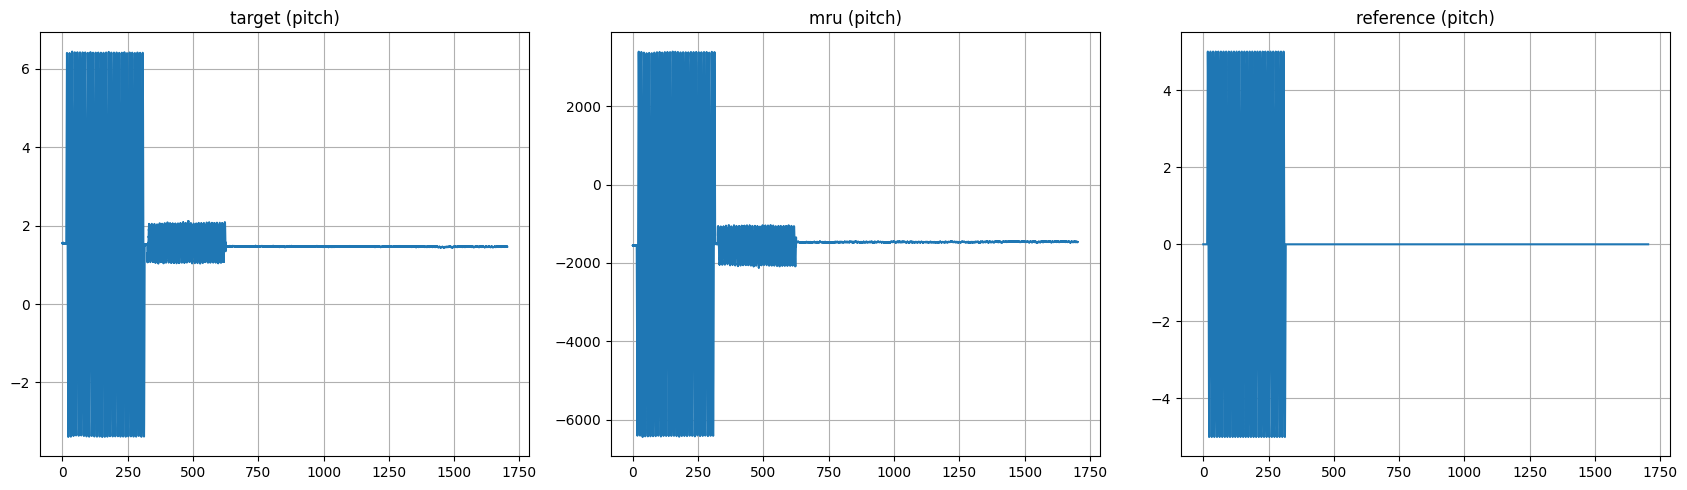

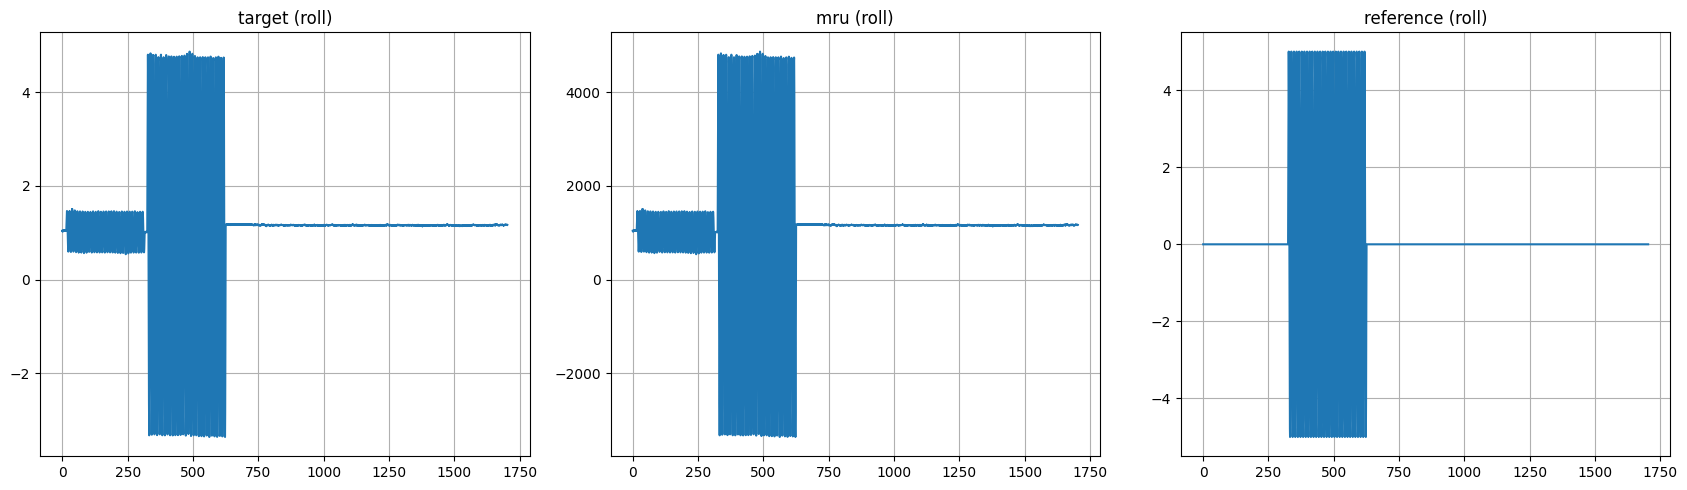

In [175]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll']:
    compareAxis({
        f'target ({var})':  df[f'target_{var}'], 
        f'mru ({var})': df[f'mru_{var}'],
        f'reference ({var})': df[f'ref_{var}'],
    }, time=df.time, figsize=(17, 5))

# ENCONTRANDO CATEGORIAS
- status pode ser = 'none' (nenhum/estabilizando), 'pitch' (variando pitch), 'roll' (variando roll), 'static' (parado)
- Implementação da detecção pelos dados utilizando os intervalos com folgas de 10s:

In [176]:
conditions = [
    (df['time'] >= 15) & (df['time'] < 315),  # 300s variando pitch
    (df['time'] >= 325) & (df['time'] < 625), # 300s variando roll
    (df['time'] >= 635)                       # estático (parado)
]

choices = ['pitch', 'roll', 'static']
df['status'] = np.select(conditions, choices, default='none')
df['status'].value_counts()

status
static    10679
pitch      3000
roll       2998
none        350
Name: count, dtype: int64

In [177]:
df

,target_wz,target_az,target_yaw,target_ax,target_h,time,target_pitch,target_ay,target_wx,target_wy,target_roll,target_tmp,ref_wz,ref_az,ref_yaw,ref_ax,ref_h,ref_pitch,ref_ay,ref_wx,ref_wy,ref_roll,ref_tmp,mru_wz,mru_az,mru_yaw,mru_ax,mru_h,mru_pitch,mru_ay,mru_wx,mru_wy,mru_roll,mru_tmp,status
0,0.10067,-0.270526,1.551,-0.173754,-0.024,7.152557e-07,1.548,9.786821,-0.04969,0.02252,1.043,43.8,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.000,-2252.0,997978.0,1551.0,-17718.0,-0.024,-1548.0,-27586.0,-4969.0,10067.0,1043.0,43.8,none
1,0.01753,-0.258072,1.565,-0.171538,-0.022,9.435034e-02,1.546,9.779888,0.07862,0.00236,1.038,43.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.100,-236.0,997271.0,1565.0,-17492.0,-0.022,-1546.0,-26316.0,7862.0,1753.0,1038.0,43.7,none
2,-0.06852,-0.248520,1.572,-0.157554,-0.019,2.007830e-01,1.549,9.791499,-0.11278,0.04887,1.032,43.8,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.200,-4887.0,998455.0,1572.0,-16066.0,-0.019,-1549.0,-25342.0,-11278.0,-6852.0,1032.0,43.8,none
3,0.03072,-0.275959,1.578,-0.169537,-0.017,2.974703e-01,1.549,9.768649,-0.04654,0.01132,1.031,43.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.300,-1132.0,996125.0,1578.0,-17288.0,-0.017,-1549.0,-28140.0,-4654.0,3072.0,1031.0,43.7,none
4,-0.01811,-0.270291,1.592,-0.161339,-0.014,4.027123e-01,1.556,9.781780,-0.00709,0.02012,1.039,43.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.400,-2012.0,997464.0,1592.0,-16452.0,-0.014,-1556.0,-27562.0,-709.0,-1811.0,1039.0,43.7,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17022,0.09952,-0.244539,24.694,-0.195751,-0.006,1.702951e+03,1.469,9.790587,-0.02678,0.05596,1.171,44.6,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1702.935,-5596.0,998362.0,24694.0,-19961.0,-0.006,-1469.0,-24936.0,-2678.0,9952.0,1171.0,44.6,static
17023,0.04221,-0.253227,24.696,-0.198349,-0.006,1.703046e+03,1.468,9.772209,-0.06341,0.10312,1.172,44.8,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1703.035,-10312.0,996488.0,24696.0,-20226.0,-0.006,-1468.0,-25822.0,-6341.0,4221.0,1172.0,44.8,static
17024,0.04384,-0.246510,24.698,-0.202625,-0.006,1.703146e+03,1.469,9.783653,0.05080,-0.02902,1.171,44.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1703.135,2902.0,997655.0,24698.0,-20662.0,-0.006,-1469.0,-25137.0,5080.0,4384.0,1171.0,44.7,static
17025,-0.05613,-0.236007,24.699,-0.191897,-0.006,1.703249e+03,1.470,9.777573,-0.05271,0.01943,1.171,44.7,0.0,9.8067,108.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,1703.235,-1943.0,997035.0,24699.0,-19568.0,-0.006,-1470.0,-24066.0,-5271.0,-5613.0,1171.0,44.7,static


# SALVANDO DADOS

In [178]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)